# Étape 3 : Feature Engineering - PySpark

## Objectif
Créer des features (variables) pertinentes à partir des données brutes pour améliorer les performances du modèle ML **en utilisant PySpark**.

## Plan
1. Charger le dataset fusionné
2. Créer des features temporelles (heure, jour, weekend, rush hour...)
3. Créer des features météo enrichies (catégories de température, intensité de pluie)
4. Encoder les variables catégorielles (One-Hot Encoding)
5. Analyser les corrélations avec la variable cible
6. Sauvegarder le dataset final pour le ML

---

## 3.1 Initialisation Spark et Chargement des Données

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, hour, dayofweek, month, when, lit,
    mean, min as spark_min, max as spark_max,
    count, desc
)
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
import matplotlib.pyplot as plt
import seaborn as sns

# Créer Spark Session
spark = SparkSession.builder \
    .appName("MeteoVelo - Feature Engineering") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Session créée!")

Spark Session créée!


In [2]:
# Charger le dataset fusionné depuis l'étape 2
print("📂 Chargement du dataset fusionné...\n")

df = spark.read.csv('../CSVs/data_merged_spark.csv', 
                    header=True, 
                    inferSchema=True, 
                    sep=';')

print(f"Dataset chargé : {df.count():,} lignes x {len(df.columns)} colonnes")
print("\n" + "="*80)
print("Aperçu des données :")
df.show(10, truncate=False)
df.printSchema()

📂 Chargement du dataset fusionné...

Dataset chargé : 696 lignes x 4 colonnes

Aperçu des données :
+-------------------+--------+------------------+-------------------+
|timestamp          |nb_velos|temperature       |precipitation      |
+-------------------+--------+------------------+-------------------+
|2022-04-01 00:00:00|3607    |7.3980263157894735|0.10000000149011612|
|2022-04-01 01:00:00|1762    |6.958333333333333 |0.0                |
|2022-04-01 02:00:00|1207    |6.493589743589744 |0.10000000149011612|
|2022-04-01 03:00:00|878     |4.5082236842105265|0.18252427572185553|
|2022-04-01 04:00:00|652     |2.695723684210526 |0.1714953304938624 |
|2022-04-01 05:00:00|885     |2.10625           |0.15500000279683332|
|2022-04-01 06:00:00|2315    |1.5480769230769231|0.16033898617251444|
|2022-04-01 07:00:00|9696    |1.3658088235294117|0.14008439052457045|
|2022-04-01 08:00:00|21176   |1.5135135135135136|0.12518518716096877|
|2022-04-01 09:00:00|11340   |1.8597972972972974|0.100000001

---
## 3.2 Création des Features Temporelles

### Pourquoi ?
Le trafic vélo a des **patterns temporels très marqués** :
- **Heures de pointe** (7-9h et 17-19h) → beaucoup de vélos
- **Nuit** (0-5h) → peu de vélos
- **Week-end** → comportement différent du lundi-vendredi
- **Jour de la semaine** → chaque jour a son profil

### Features à créer :
1. **`hour`** : Heure de la journée (0-23)
2. **`day_of_week`** : Jour de la semaine (1=Lundi, 7=Dimanche)
3. **`is_weekend`** : Weekend ou pas (0/1)
4. **`is_rush_hour`** : Heure de pointe ou pas (0/1)
5. **`month`** : Mois (pour des données multi-mois)

In [3]:
print("Création des features temporelles...\n")

# 1. Heure de la journée (0-23)
df = df.withColumn('hour', hour(col('timestamp')))
print("Feature 'hour' créée")

# 2. Jour de la semaine (1=Lundi, 7=Dimanche en PySpark dayofweek)
# Note : PySpark dayofweek retourne 1=Dimanche, 2=Lundi, ..., 7=Samedi
# On va ajuster pour avoir 1=Lundi, 7=Dimanche
df = df.withColumn('day_of_week_raw', dayofweek(col('timestamp')))
df = df.withColumn('day_of_week', 
                   when(col('day_of_week_raw') == 1, 7)  # Dimanche = 7
                   .otherwise(col('day_of_week_raw') - 1))  # Lundi=1, ..., Samedi=6
df = df.drop('day_of_week_raw')
print("Feature 'day_of_week' créée (1=Lundi, 7=Dimanche)")

# 3. Weekend (Samedi=6, Dimanche=7)
df = df.withColumn('is_weekend', 
                   when(col('day_of_week').isin([6, 7]), 1)
                   .otherwise(0))
print("Feature 'is_weekend' créée")

# 4. Heures de pointe (7-9h et 17-19h)
df = df.withColumn('is_rush_hour',
                   when((col('hour') >= 7) & (col('hour') <= 9), 1)
                   .when((col('hour') >= 17) & (col('hour') <= 19), 1)
                   .otherwise(0))
print("Feature 'is_rush_hour' créée")

# 5. Mois (pour des analyses futures multi-mois)
df = df.withColumn('month', month(col('timestamp')))
print("Feature 'month' créée")

print("\n" + "="*80)
print("Dataset avec features temporelles :")
df.select('timestamp', 'nb_velos', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'month').show(10, truncate=False)

Création des features temporelles...

Feature 'hour' créée
Feature 'day_of_week' créée (1=Lundi, 7=Dimanche)
Feature 'is_weekend' créée
Feature 'is_rush_hour' créée
Feature 'month' créée

Dataset avec features temporelles :
+-------------------+--------+----+-----------+----------+------------+-----+
|timestamp          |nb_velos|hour|day_of_week|is_weekend|is_rush_hour|month|
+-------------------+--------+----+-----------+----------+------------+-----+
|2022-04-01 00:00:00|3607    |0   |5          |0         |0           |4    |
|2022-04-01 01:00:00|1762    |1   |5          |0         |0           |4    |
|2022-04-01 02:00:00|1207    |2   |5          |0         |0           |4    |
|2022-04-01 03:00:00|878     |3   |5          |0         |0           |4    |
|2022-04-01 04:00:00|652     |4   |5          |0         |0           |4    |
|2022-04-01 05:00:00|885     |5   |5          |0         |0           |4    |
|2022-04-01 06:00:00|2315    |6   |5          |0         |0           |4  

Trafic moyen par heure de la journée :
+----+------------------+
|hour|avg_velos         |
+----+------------------+
|0   |3027.206896551724 |
|1   |1833.5862068965516|
|2   |1103.8275862068965|
|3   |918.4137931034483 |
|4   |848.2758620689655 |
|5   |1071.4827586206898|
|6   |2867.862068965517 |
|7   |10670.172413793103|
|8   |25467.896551724138|
|9   |12997.793103448275|
|10  |8617.068965517241 |
|11  |9839.275862068966 |
|12  |13342.551724137931|
|13  |12089.724137931034|
|14  |11280.724137931034|
|15  |12301.48275862069 |
|16  |15858.034482758621|
|17  |23774.41379310345 |
|18  |26326.655172413793|
|19  |19205.172413793105|
|20  |10894.379310344828|
|21  |6650.689655172414 |
|22  |5830.9655172413795|
|23  |4929.206896551724 |
+----+------------------+



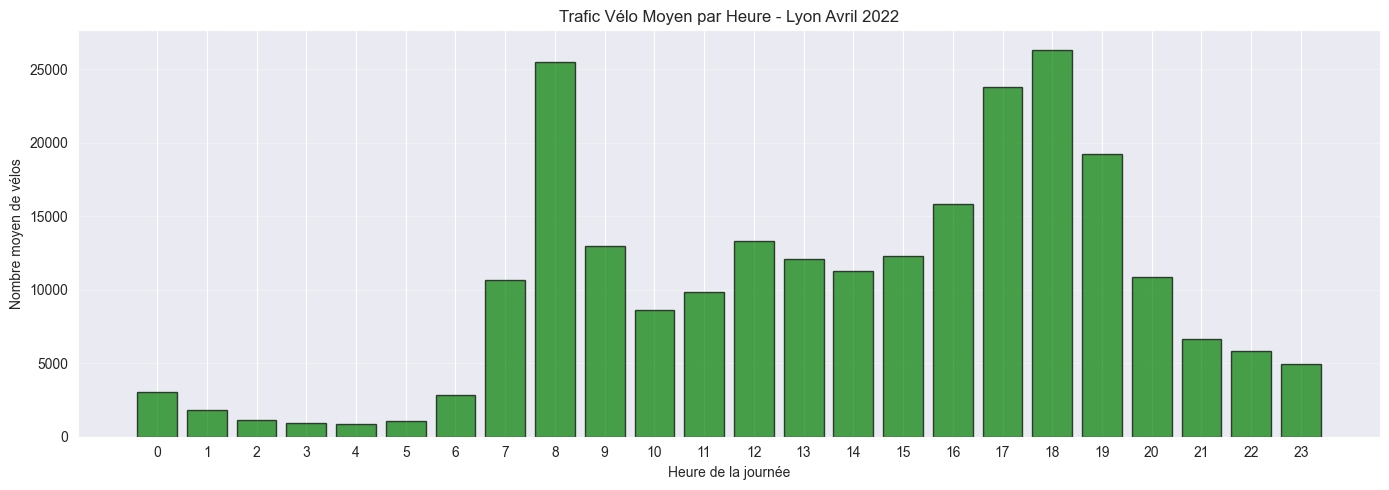


On voit clairement les pics aux heures de pointe (8h et 18h)


In [4]:
# Analyse : trafic moyen par heure de la journée
print("Trafic moyen par heure de la journée :")
print("="*80)

trafic_par_heure = df.groupBy('hour') \
    .agg(mean('nb_velos').alias('avg_velos')) \
    .orderBy('hour')

trafic_par_heure.show(24, truncate=False)

# Visualisation
trafic_par_heure_pd = trafic_par_heure.toPandas()
plt.figure(figsize=(14, 5))
plt.bar(trafic_par_heure_pd['hour'], trafic_par_heure_pd['avg_velos'], 
        color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre moyen de vélos')
plt.title('Trafic Vélo Moyen par Heure - Lyon Avril 2022')
plt.xticks(range(24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nOn voit clairement les pics aux heures de pointe (8h et 18h)")

Trafic moyen par jour de la semaine :
+-----------+------------------+
|day_of_week|avg_velos         |
+-----------+------------------+
|1          |9577.708333333334 |
|2          |12093.84375       |
|3          |12256.947916666666|
|4          |12506.625         |
|5          |10823.041666666666|
|6          |6415.395833333333 |
|7          |6648.375          |
+-----------+------------------+



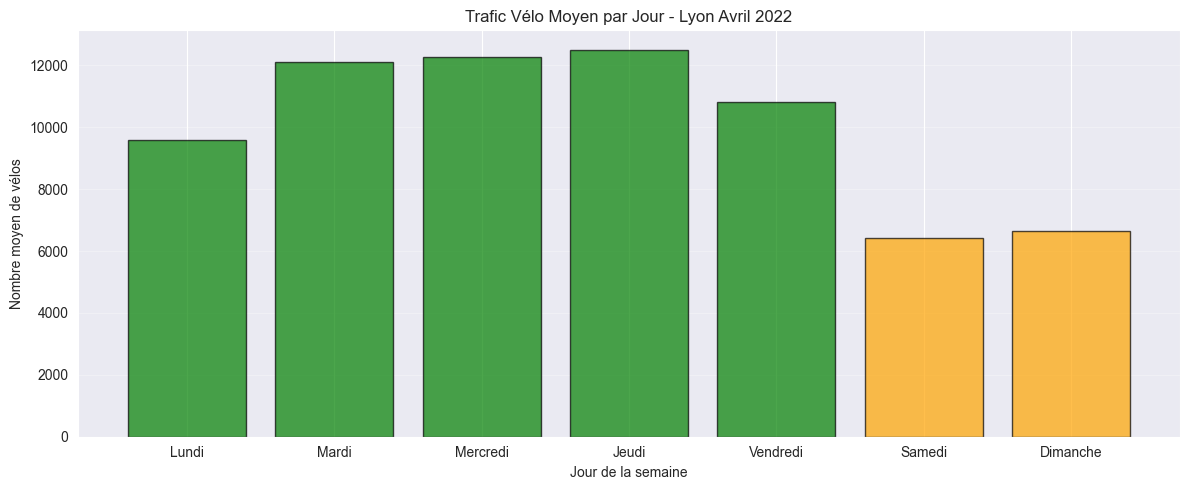


Le trafic est plus élevé en semaine (travail) qu'en weekend (loisir)


In [5]:
# Analyse : trafic moyen par jour de la semaine
print("Trafic moyen par jour de la semaine :")
print("="*80)

trafic_par_jour = df.groupBy('day_of_week') \
    .agg(mean('nb_velos').alias('avg_velos')) \
    .orderBy('day_of_week')

trafic_par_jour.show(truncate=False)

# Visualisation
trafic_par_jour_pd = trafic_par_jour.toPandas()
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

plt.figure(figsize=(12, 5))
plt.bar(jours, trafic_par_jour_pd['avg_velos'], 
        color=['green']*5 + ['orange']*2, alpha=0.7, edgecolor='black')
plt.xlabel('Jour de la semaine')
plt.ylabel('Nombre moyen de vélos')
plt.title('Trafic Vélo Moyen par Jour - Lyon Avril 2022')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nLe trafic est plus élevé en semaine (travail) qu'en weekend (loisir)")

---
## 3.3 Création des Features Météo Enrichies

### Pourquoi ?
Les valeurs brutes (température en °C, pluie en mm) peuvent être enrichies en **catégories** plus interprétables.

### Features à créer :
1. **`is_raining`** : Booléen (précipitation > 0)
2. **`rain_intensity`** : Catégories (no_rain, light, moderate, heavy)
   - Aucune : 0mm
   - Légère : 0-0.2mm
   - Modérée : 0.2-0.5mm
   - Forte : >0.5mm
3. **`temp_category`** : Catégories de température
   - Froid : <5°C
   - Frais : 5-10°C
   - Doux : 10-15°C
   - Chaud : 15-20°C
   - Très chaud : >20°C

In [6]:
print("Création des features météo...\n")

# 1. Booléen : est-ce qu'il pleut ?
df = df.withColumn('is_raining',
                   when(col('precipitation') > 0, 1)
                   .otherwise(0))
print("Feature 'is_raining' créée")

# 2. Intensité de la pluie (catégories)
df = df.withColumn('rain_intensity',
                   when(col('precipitation') == 0, 'no_rain')
                   .when(col('precipitation') <= 0.2, 'light')
                   .when(col('precipitation') <= 0.5, 'moderate')
                   .otherwise('heavy'))
print("Feature 'rain_intensity' créée")

# 3. Catégories de température
df = df.withColumn('temp_category',
                   when(col('temperature') < 5, 'cold')
                   .when(col('temperature') < 10, 'cool')
                   .when(col('temperature') < 15, 'mild')
                   .when(col('temperature') < 20, 'warm')
                   .otherwise('hot'))
print("Feature 'temp_category' créée")

print("\n" + "="*80)
print("Dataset avec features météo :")
df.select('timestamp', 'nb_velos', 'temperature', 'temp_category', 
          'precipitation', 'is_raining', 'rain_intensity').show(10, truncate=False)

Création des features météo...

Feature 'is_raining' créée
Feature 'rain_intensity' créée
Feature 'temp_category' créée

Dataset avec features météo :
+-------------------+--------+------------------+-------------+-------------------+----------+--------------+
|timestamp          |nb_velos|temperature       |temp_category|precipitation      |is_raining|rain_intensity|
+-------------------+--------+------------------+-------------+-------------------+----------+--------------+
|2022-04-01 00:00:00|3607    |7.3980263157894735|cool         |0.10000000149011612|1         |light         |
|2022-04-01 01:00:00|1762    |6.958333333333333 |cool         |0.0                |0         |no_rain       |
|2022-04-01 02:00:00|1207    |6.493589743589744 |cool         |0.10000000149011612|1         |light         |
|2022-04-01 03:00:00|878     |4.5082236842105265|cold         |0.18252427572185553|1         |light         |
|2022-04-01 04:00:00|652     |2.695723684210526 |cold         |0.17149533049386

Distribution des intensités de pluie :
+--------------+-----+
|rain_intensity|count|
+--------------+-----+
|no_rain       |580  |
|light         |93   |
|moderate      |21   |
|heavy         |2    |
+--------------+-----+



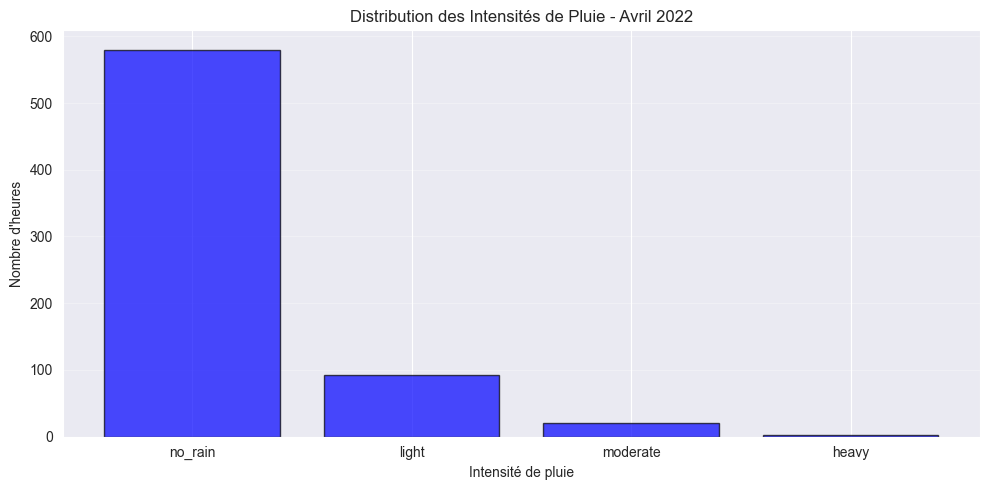

In [7]:
# Analyse : distribution des intensités de pluie
print("Distribution des intensités de pluie :")
print("="*80)

rain_dist = df.groupBy('rain_intensity') \
    .agg(count('*').alias('count')) \
    .orderBy(desc('count'))

rain_dist.show(truncate=False)

# Visualisation
rain_dist_pd = rain_dist.toPandas()
plt.figure(figsize=(10, 5))
plt.bar(rain_dist_pd['rain_intensity'], rain_dist_pd['count'], 
        color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Intensité de pluie')
plt.ylabel('Nombre d\'heures')
plt.title('Distribution des Intensités de Pluie - Avril 2022')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Trafic moyen par catégorie de température :
+-------------+------------------+-----+
|temp_category|avg_velos         |count|
+-------------+------------------+-----+
|hot          |20453.927272727273|55   |
|warm         |12630.644329896908|194  |
|mild         |8355.877323420074 |269  |
|cool         |7492.441860465116 |86   |
|cold         |5905.076086956522 |92   |
+-------------+------------------+-----+



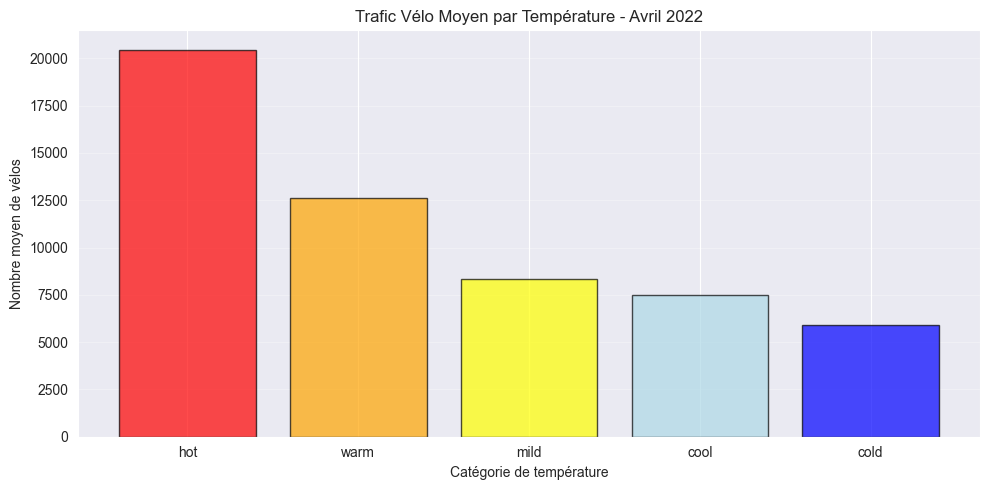


Le trafic vélo augmente avec la température (meilleur confort)


In [8]:
# Analyse : trafic moyen par catégorie de température
print("Trafic moyen par catégorie de température :")
print("="*80)

trafic_par_temp = df.groupBy('temp_category') \
    .agg(mean('nb_velos').alias('avg_velos'),
         count('*').alias('count')) \
    .orderBy('avg_velos', ascending=False)

trafic_par_temp.show(truncate=False)

# Visualisation
trafic_par_temp_pd = trafic_par_temp.toPandas().sort_values('avg_velos', ascending=False)
plt.figure(figsize=(10, 5))
colors = {'hot': 'red', 'warm': 'orange', 'mild': 'yellow', 'cool': 'lightblue', 'cold': 'blue'}
bar_colors = [colors.get(cat, 'gray') for cat in trafic_par_temp_pd['temp_category']]

plt.bar(trafic_par_temp_pd['temp_category'], trafic_par_temp_pd['avg_velos'], 
        color=bar_colors, alpha=0.7, edgecolor='black')
plt.xlabel('Catégorie de température')
plt.ylabel('Nombre moyen de vélos')
plt.title('Trafic Vélo Moyen par Température - Avril 2022')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nLe trafic vélo augmente avec la température (meilleur confort)")

---
## 3.4 One-Hot Encoding des Variables Catégorielles

### Pourquoi ?
Les algorithmes de ML (régression, random forest, etc.) ne comprennent que les **nombres**.
Les variables catégorielles (texte) doivent être converties en nombres.

### Technique : One-Hot Encoding
Transformer `rain_intensity` en plusieurs colonnes binaires (0/1) :
- `rain_intensity_no_rain`
- `rain_intensity_light`
- `rain_intensity_moderate`
- `rain_intensity_heavy`

### En PySpark :
1. **StringIndexer** : Convertir texte → index (0, 1, 2, ...)
2. **OneHotEncoder** : Convertir index → vecteur binaire

In [9]:
print("One-Hot Encoding des variables catégorielles...\n")

# Variables catégorielles à encoder
categorical_cols = ['rain_intensity', 'temp_category']

# Étape 1 : StringIndexer (texte → index)
from pyspark.ml import Pipeline

indexers = [StringIndexer(inputCol=col_name, outputCol=col_name + '_index', handleInvalid='keep') 
            for col_name in categorical_cols]

# Étape 2 : OneHotEncoder (index → vecteur binaire)
encoders = [OneHotEncoder(inputCol=col_name + '_index', outputCol=col_name + '_encoded') 
            for col_name in categorical_cols]

# Pipeline : appliquer StringIndexer puis OneHotEncoder
pipeline = Pipeline(stages=indexers + encoders)
model = pipeline.fit(df)
df_encoded = model.transform(df)

print("One-Hot Encoding appliqué!")
print("\nColonnes ajoutées :")
for col_name in categorical_cols:
    print(f"  - {col_name}_index")
    print(f"  - {col_name}_encoded")

print("\n" + "="*80)
print("Aperçu du dataset encodé :")
df_encoded.select('rain_intensity', 'rain_intensity_index', 'rain_intensity_encoded',
                  'temp_category', 'temp_category_index', 'temp_category_encoded').show(10, truncate=False)

One-Hot Encoding des variables catégorielles...

One-Hot Encoding appliqué!

Colonnes ajoutées :
  - rain_intensity_index
  - rain_intensity_encoded
  - temp_category_index
  - temp_category_encoded

Aperçu du dataset encodé :
+--------------+--------------------+----------------------+-------------+-------------------+---------------------+
|rain_intensity|rain_intensity_index|rain_intensity_encoded|temp_category|temp_category_index|temp_category_encoded|
+--------------+--------------------+----------------------+-------------+-------------------+---------------------+
|light         |1.0                 |(4,[1],[1.0])         |cool         |3.0                |(5,[3],[1.0])        |
|no_rain       |0.0                 |(4,[0],[1.0])         |cool         |3.0                |(5,[3],[1.0])        |
|light         |1.0                 |(4,[1],[1.0])         |cool         |3.0                |(5,[3],[1.0])        |
|light         |1.0                 |(4,[1],[1.0])         |cold       

**💡 Note :** Les colonnes encodées sont des vecteurs Spark (`SparseVector`), utilisables directement par les modèles ML de PySpark.

---
## 3.5 Analyse de Corrélation avec la Variable Cible

### Objectif :
Identifier quelles features ont le plus d'impact sur `nb_velos` (notre cible).

### Méthode :
Calculer la corrélation de Pearson entre chaque feature numérique et `nb_velos`.

Analyse de corrélation avec la variable cible 'nb_velos' :

Corrélations avec 'nb_velos' :
nb_velos         1.000000
is_rush_hour     0.618945
hour             0.399215
temperature      0.389616
precipitation   -0.087915
is_raining      -0.143904
day_of_week     -0.165775
is_weekend      -0.242351
Name: nb_velos, dtype: float64


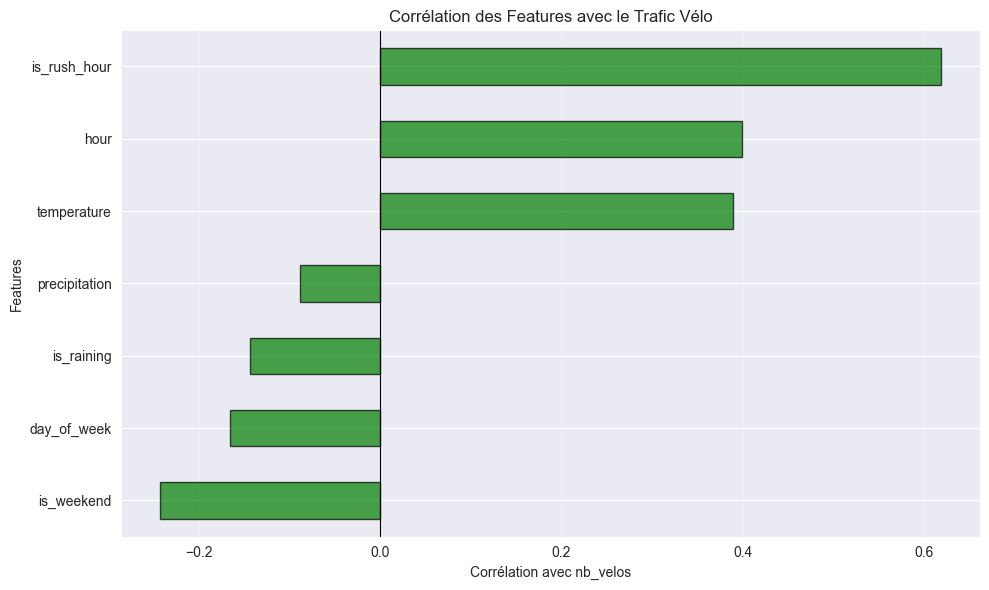


Interprétation :
- Les features avec corrélation positive augmentent le trafic vélo
- Les features avec corrélation négative diminuent le trafic vélo
- Plus la valeur absolue est élevée, plus l'impact est fort


In [10]:
print("Analyse de corrélation avec la variable cible 'nb_velos' :")
print("="*80)

# Sélectionner les features numériques pour la corrélation
numeric_features = ['hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 
                    'temperature', 'precipitation', 'is_raining']

# Convertir en Pandas pour utiliser corr()
df_corr = df_encoded.select(['nb_velos'] + numeric_features).toPandas()
correlations = df_corr.corr()['nb_velos'].sort_values(ascending=False)

print("\nCorrélations avec 'nb_velos' :")
print(correlations)

# Visualisation
plt.figure(figsize=(10, 6))
correlations.drop('nb_velos').sort_values().plot(kind='barh', color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Corrélation avec nb_velos')
plt.ylabel('Features')
plt.title('Corrélation des Features avec le Trafic Vélo')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nInterprétation :")
print("- Les features avec corrélation positive augmentent le trafic vélo")
print("- Les features avec corrélation négative diminuent le trafic vélo")
print("- Plus la valeur absolue est élevée, plus l'impact est fort")

---
## 3.6 Création du Dataset Final pour le ML

### Colonnes à conserver :
- **Variable cible** : `nb_velos`
- **Features numériques** : `temperature`, `precipitation`, `hour`, `day_of_week`, `is_weekend`, `is_rush_hour`, `month`, `is_raining`
- **Features encodées** : `rain_intensity_encoded`, `temp_category_encoded`
- **Timestamp** : pour référence (non utilisé dans le modèle)

### Colonnes à exclure :
- Les colonnes intermédiaires (`rain_intensity_index`, etc.)
- Les colonnes catégorielles brutes (déjà encodées)

In [11]:
print("Création du dataset final pour le ML...\n")

# Colonnes à conserver
final_cols = [
    'timestamp',           # Pour référence
    'nb_velos',            # Variable cible
    'temperature',         # Feature numérique
    'precipitation',       # Feature numérique
    'hour',                # Feature temporelle
    'day_of_week',         # Feature temporelle
    'is_weekend',          # Feature temporelle
    'is_rush_hour',        # Feature temporelle
    'month',               # Feature temporelle
    'is_raining',          # Feature météo
    'rain_intensity',      # Feature catégorielle (pour référence)
    'temp_category',       # Feature catégorielle (pour référence)
    'rain_intensity_encoded',  # Feature encodée
    'temp_category_encoded'    # Feature encodée
]

df_final = df_encoded.select(final_cols)

print(f"Dataset final créé : {df_final.count():,} lignes x {len(df_final.columns)} colonnes")
print("\n" + "="*80)
print("Aperçu du dataset final :")
df_final.show(10, truncate=False)

print("\n" + "="*80)
print("Schema du dataset final :")
df_final.printSchema()

Création du dataset final pour le ML...

Dataset final créé : 696 lignes x 14 colonnes

Aperçu du dataset final :
+-------------------+--------+------------------+-------------------+----+-----------+----------+------------+-----+----------+--------------+-------------+----------------------+---------------------+
|timestamp          |nb_velos|temperature       |precipitation      |hour|day_of_week|is_weekend|is_rush_hour|month|is_raining|rain_intensity|temp_category|rain_intensity_encoded|temp_category_encoded|
+-------------------+--------+------------------+-------------------+----+-----------+----------+------------+-----+----------+--------------+-------------+----------------------+---------------------+
|2022-04-01 00:00:00|3607    |7.3980263157894735|0.10000000149011612|0   |5          |0         |0           |4    |1         |light         |cool         |(4,[1],[1.0])         |(5,[3],[1.0])        |
|2022-04-01 01:00:00|1762    |6.958333333333333 |0.0                |1   |5   

---
## 3.7 Statistiques Finales du Dataset

In [12]:
print("Statistiques descriptives du dataset final :")
print("="*80)

# Statistiques des features numériques
df_final.select('nb_velos', 'temperature', 'precipitation', 'hour', 
                'day_of_week', 'is_weekend', 'is_rush_hour').describe().show()

# Comptage par catégories
print("\nDistribution des catégories de température :")
df_final.groupBy('temp_category').count().orderBy(desc('count')).show()

print("\nDistribution des intensités de pluie :")
df_final.groupBy('rain_intensity').count().orderBy(desc('count')).show()

print("\nDistribution weekend vs semaine :")
df_final.groupBy('is_weekend').count().show()

Statistiques descriptives du dataset final :
+-------+-----------------+------------------+-------------------+-----------------+------------------+-------------------+-------------------+
|summary|         nb_velos|       temperature|      precipitation|             hour|       day_of_week|         is_weekend|       is_rush_hour|
+-------+-----------------+------------------+-------------------+-----------------+------------------+-------------------+-------------------+
|  count|              696|               696|                696|              696|               696|                696|                696|
|   mean|10072.78591954023|12.710508000967204|0.02561459049997351|             11.5|4.0344827586206895|0.27586206896551724|               0.25|
| stddev|9024.364654341893| 5.416149960525314|0.06977961759361188|6.927164752681386|1.9750867074284557|0.44726906385310145|0.43332410984465425|
|    min|              225|0.2944078947368421|                0.0|                0|       

---
## 3.8 Sauvegarde du Dataset Final

In [13]:
# Sauvegarder le dataset final
output_path_parquet = '../data/data_final_spark.parquet'
output_path_csv = '../CSVs/data_final_spark.csv'

# Option 1 : Format Parquet (recommandé pour PySpark - garde les types)
df_final.write.parquet(output_path_parquet, mode='overwrite')
print(f"Dataset sauvegardé en Parquet : {output_path_parquet}")

# Option 2 : Format CSV (pour visualisation/export)
# Note : les vecteurs encodés seront convertis en string
df_final_csv = df_final.drop('rain_intensity_encoded', 'temp_category_encoded')  # Exclure les vecteurs pour CSV
df_final_csv.toPandas().to_csv(output_path_csv, index=False, sep=';')
print(f"Dataset sauvegardé en CSV (sans vecteurs) : {output_path_csv}")

print("\n" + "="*80)
print("Dataset final prêt pour le Machine Learning!")
print("="*80)
print(f"Dimensions : {df_final.count():,} lignes x {len(df_final.columns)} colonnes")
print(f"Période : {df_final.agg(spark_min('timestamp')).collect()[0][0]} → {df_final.agg(spark_max('timestamp')).collect()[0][0]}")
print(f"Variable cible : nb_velos")
print(f"Features : {len(df_final.columns) - 2} (numériques + encodées)")

Dataset sauvegardé en Parquet : ../data/data_final_spark.parquet
Dataset sauvegardé en CSV (sans vecteurs) : ../CSVs/data_final_spark.csv

Dataset final prêt pour le Machine Learning!
Dimensions : 696 lignes x 14 colonnes
Période : 2022-04-01 00:00:00 → 2022-04-29 23:00:00
Variable cible : nb_velos
Features : 12 (numériques + encodées)


---
## 3.9 Résumé de l'Étape 3

### Ce qui a été fait :

1. **Features Temporelles Créées**
   - `hour` : Heure de la journée (0-23)
   - `day_of_week` : Jour de la semaine (1=Lundi, 7=Dimanche)
   - `is_weekend` : Weekend (0/1)
   - `is_rush_hour` : Heure de pointe 7-9h et 17-19h (0/1)
   - `month` : Mois

2. **Features Météo Enrichies**
   - `is_raining` : Booléen (0/1)
   - `rain_intensity` : Catégories (no_rain, light, moderate, heavy)
   - `temp_category` : Catégories (cold, cool, mild, warm, hot)

3. **One-Hot Encoding**
   - Variables catégorielles converties en vecteurs binaires
   - Utilisables directement par les modèles PySpark ML

4. **Analyse de Corrélation**
   - Identification des features les plus impactantes
   - Visualisations des patterns temporels et météo

5. **Dataset Final Sauvegardé**
   - Format Parquet (optimal pour PySpark)
   - Format CSV (pour visualisation)

### Dataset Final :
- **Lignes** : 696 (heures d'avril 2022)
- **Variable cible** : `nb_velos` (trafic vélo total Lyon)
- **Features numériques** : 8 (temperature, precipitation, hour, day_of_week, is_weekend, is_rush_hour, month, is_raining)
- **Features encodées** : 2 vecteurs (rain_intensity, temp_category)

### Prochaine Étape :
**Étape 4 : Modélisation Machine Learning**
- Diviser données en train/test
- Entraîner différents modèles (Régression Linéaire, Random Forest, Gradient Boosting)
- Évaluer les performances (RMSE, MAE, R²)
- Sélectionner le meilleur modèle

---
**Étape 3 terminée !**

In [14]:
# Arrêter la Spark Session
spark.stop()
print("Spark Session arrêtée!")

Spark Session arrêtée!
